In [ ]:
!pip install -q segmentation-models-pytorch albumentations torchmetrics pytorch-lightning clearml python-dotenv gdown

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 79.5 MB/s eta 0:00:00


In [ ]:
import os
import math
import shutil
import torch
import pandas as pd
import matplotlib.pyplot as plt
import albumentations as A
import segmentation_models_pytorch as smp
import pytorch_lightning as pl
from pytorch_lightning.callbacks import Callback, TQDMProgressBar
from torch.utils.data import DataLoader, Dataset
from torchmetrics import JaccardIndex
from albumentations.pytorch import ToTensorV2
from clearml import Task
import cv2
import numpy as np
from google.colab import files
from dotenv import load_dotenv
import gdown
import zipfile
from concurrent.futures import ProcessPoolExecutor

In [ ]:
from google.colab import userdata, drive

os.environ['CLEARML_API_ACCESS_KEY'] = userdata.get('CLEARML_API_ACCESS_KEY')
os.environ['CLEARML_API_SECRET_KEY'] = userdata.get('CLEARML_API_SECRET_KEY')

In [ ]:
drive.mount('/content/drive')


source_path = '/content/drive/MyDrive/'

tasks = [
    {
        "files": ["leftImg8bit_trainvaltest.zip", "gtFine_trainvaltest.zip"],
        "dest": "/content/data/cityscapes/"
    }
]

for task in tasks:
    if not os.path.exists(task["dest"]):
        os.makedirs(task["dest"])

    for zip_file in task["files"]:
        full_path = os.path.join(source_path, zip_file)

        if os.path.exists(full_path):
            print(f"Unpacking {zip_file} in {task['dest']}...")
            !unzip -q -o "{full_path}" -d "{task['dest']}"
        else:
            print(f"Error, file not found: {full_path}")

Mounted at /content/drive
Unpacking leftImg8bit_trainvaltest.zip in /content/data/cityscapes/...
Unpacking gtFine_trainvaltest.zip in /content/data/cityscapes/...


In [ ]:
CONFIG = {
    "project_name": "Segmentation_Urban_Scene_CourseWork",
    "task_name": "SegFormer_B2_Cityscapes_E4_SourceConsistency",
    "data_dir": "./data/cityscapes",
    "encoder": "mit_b2",
    "encoder_weights": "imagenet",
    "classes": 19,
    "batch_size": 8,
    "lr": 1.5e-4,
    "momentum": 0.9,
    "weight_decay": 0.01,
    "epochs": 24,
    "image_size": (512, 1024),
    "num_workers": 4,
    "check_val_every_n_epoch": 2,
    "early_stopping_patience": 4,
    "early_stopping_min_delta": 0.001,
    "consistency_weight": 0.15,
    "consistency_confidence_threshold": 0.80,
    "consistency_rampup_epochs": 4,
    "consistency_every_n_steps": 2,
    "device": "cuda" if torch.cuda.is_available() else "cpu"
}

torch.set_float32_matmul_precision('medium')
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

task = Task.init(
    project_name=CONFIG["project_name"],
    task_name=CONFIG["task_name"],
    output_uri=False
)
task.connect(CONFIG)


ClearML Task: created new task id=e7bc023c295e4ef89b1b94159b933b3f


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


ClearML results page: https://app.clear.ml/projects/588d5d925230490b9f98b1007b4c7fa0/experiments/e7bc023c295e4ef89b1b94159b933b3f/output/log


{'project_name': 'Segmentation_Urban_Scene_CourseWork',
 'task_name': 'SegFormer_B2_Cityscapes_E4_SourceConsistency',
 'data_dir': './data/cityscapes',
 'encoder': 'mit_b2',
 'encoder_weights': 'imagenet',
 'classes': 19,
 'batch_size': 8,
 'lr': 0.00015,
 'momentum': 0.9,
 'weight_decay': 0.01,
 'epochs': 24,
 'image_size': (512, 1024),
 'num_workers': 4,
 'check_val_every_n_epoch': 2,
 'early_stopping_patience': 4,
 'early_stopping_min_delta': 0.001,
 'consistency_weight': 0.15,
 'consistency_confidence_threshold': 0.8,
 'consistency_rampup_epochs': 4,
 'consistency_every_n_steps': 2,
 'device': 'cuda'}

In [ ]:
class CityscapesDataset(Dataset):
    def __init__(
        self,
        root_dir,
        split='train',
        base_augmentation=None,
        weak_image_augmentation=None,
        strong_image_augmentation=None,
        augmentation=None,
        preprocessing=None,
    ):
        self.root_dir = root_dir
        self.images_dir = os.path.join(root_dir, 'leftImg8bit', split)
        self.masks_dir = os.path.join(root_dir, 'gtFine', split)
        self.base_augmentation = base_augmentation
        self.weak_image_augmentation = weak_image_augmentation
        self.strong_image_augmentation = strong_image_augmentation
        self.augmentation = augmentation
        self.preprocessing = preprocessing
        self.use_consistency_views = (
            split == 'train'
            and weak_image_augmentation is not None
            and strong_image_augmentation is not None
        )
        self.ids = []

        for city in os.listdir(self.images_dir):
            img_dir = os.path.join(self.images_dir, city)
            mask_dir = os.path.join(self.masks_dir, city)
            for file_name in os.listdir(img_dir):
                if file_name.endswith('_leftImg8bit.png'):
                   self.ids.append({
                       'image': os.path.join(img_dir, file_name),
                       'mask': os.path.join(mask_dir, file_name.replace('_leftImg8bit.png', '_gtFine_labelIds.png'))
                   })

        self.mapping = {
            7: 0, 8: 1, 11: 2, 12: 3, 13: 4, 17: 5, 19: 6, 20: 7, 21: 8, 22: 9,
            23: 10, 24: 11, 25: 12, 26: 13, 27: 14, 28: 15, 31: 16, 32: 17, 33: 18
        }

    def __len__(self):
        return len(self.ids)

    def _preprocess(self, image, mask):
        if self.preprocessing is None:
            return image, mask
        sample = self.preprocessing(image=image, mask=mask)
        return sample['image'], sample['mask']

    def __getitem__(self, i):
        sample = self.ids[i]
        image = cv2.imread(sample['image'])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(sample['mask'], 0)

        mask_mapped = np.ones_like(mask) * 255
        for k, v in self.mapping.items():
            mask_mapped[mask == k] = v
        mask = mask_mapped

        if self.base_augmentation:
            sample = self.base_augmentation(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']

        if self.use_consistency_views:
            weak_image = self.weak_image_augmentation(image=image)['image']
            strong_image = self.strong_image_augmentation(image=image)['image']
            weak_image, weak_mask = self._preprocess(weak_image, mask.copy())
            strong_image, strong_mask = self._preprocess(strong_image, mask.copy())
            return weak_image, strong_image, strong_mask.long()

        if self.augmentation:
            sample = self.augmentation(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']

        image, mask = self._preprocess(image, mask)
        return image, mask.long()


In [ ]:
def _to_float32(image, **kwargs):
    return image.astype(np.float32)


class RoadDataModule(pl.LightningDataModule):
    def __init__(self, data_dir, batch_size, image_size, encoder, encoder_weights, num_workers):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.image_size = image_size
        self.num_workers = num_workers
        self.preprocessing_fn = smp.encoders.get_preprocessing_fn(encoder, encoder_weights)

    def setup(self, stage=None):
        self.shared_train_transform = A.Compose([
            A.Resize(height=self.image_size[0], width=self.image_size[1]),
            A.HorizontalFlip(p=0.5),
        ])

        self.weak_image_transform = A.Compose([
            A.NoOp(),
        ])

        self.strong_image_transform = A.Compose([
            A.OneOf([
                A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0),
                A.RandomGamma(gamma_limit=(70, 120), p=1.0),
                A.RandomBrightnessContrast(brightness_limit=0.35, contrast_limit=0.35, p=1.0),
                A.RandomShadow(p=1.0),
            ], p=0.75),
            A.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.2, hue=0.08, p=0.4),
            A.OneOf([
                A.RandomFog(p=1.0),
                A.RandomRain(blur_value=3, brightness_coefficient=0.9, p=1.0),
                A.RandomSnow(p=1.0),
            ], p=0.30),
            A.OneOf([
                A.GaussNoise(p=1.0),
                A.GaussianBlur(blur_limit=(3, 7), p=1.0),
                A.MotionBlur(blur_limit=5, p=1.0),
            ], p=0.20),
        ])

        self.valid_transform = A.Compose([
            A.Resize(height=self.image_size[0], width=self.image_size[1]),
        ])

        self.preprocessing = A.Compose([
            A.Lambda(image=self.preprocessing_fn),
            A.Lambda(image=_to_float32),
            A.pytorch.ToTensorV2()
        ])

        self.train_ds = CityscapesDataset(
            self.data_dir,
            split='train',
            base_augmentation=self.shared_train_transform,
            weak_image_augmentation=self.weak_image_transform,
            strong_image_augmentation=self.strong_image_transform,
            preprocessing=self.preprocessing,
        )
        self.val_ds = CityscapesDataset(
            self.data_dir,
            split='val',
            augmentation=self.valid_transform,
            preprocessing=self.preprocessing,
        )

    def train_dataloader(self):
        return DataLoader(
            self.train_ds,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            pin_memory=True,
            persistent_workers=self.num_workers > 0,
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_ds,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=True,
            persistent_workers=self.num_workers > 0,
        )


In [ ]:
from torch.optim.lr_scheduler import SequentialLR, LinearLR, PolynomialLR

class ClearMLMetricsCallback(Callback):
    def __init__(self, task):
        super().__init__()
        self._logger = task.get_logger()

    def _log_metrics(self, trainer, stage):
        for name, value in trainer.callback_metrics.items():
            if isinstance(value, torch.Tensor):
                value = value.detach().cpu().item()
            if isinstance(value, (int, float)) and math.isfinite(value):
                self._logger.report_scalar(stage, name, value, iteration=trainer.current_epoch)

    def on_train_epoch_end(self, trainer, pl_module):
        self._log_metrics(trainer, "train")

    def on_validation_epoch_end(self, trainer, pl_module):
        self._log_metrics(trainer, "val")


class RoadModel(pl.LightningModule):
    def __init__(
        self,
        encoder,
        encoder_weights,
        in_channels,
        out_classes,
        lr=1e-4,
        weight_decay=0.01,
        epochs=24,
        consistency_weight=0.15,
        consistency_confidence_threshold=0.80,
        consistency_rampup_epochs=4,
        consistency_every_n_steps=2,
    ):
        super().__init__()
        self.save_hyperparameters()

        self.model = smp.Segformer(
            encoder_name=encoder,
            encoder_weights=encoder_weights,
            in_channels=in_channels,
            classes=out_classes,
        )

        self.loss_fn = torch.nn.CrossEntropyLoss(ignore_index=255)
        self.train_miou = JaccardIndex(task="multiclass", num_classes=out_classes, ignore_index=255)
        self.val_miou = JaccardIndex(task="multiclass", num_classes=out_classes, ignore_index=255)

    def forward(self, x):
        return self.model(x)

    def _consistency_scale(self):
        rampup_epochs = max(1, self.hparams.consistency_rampup_epochs)
        return min(1.0, float(self.current_epoch + 1) / float(rampup_epochs))

    def training_step(self, batch, batch_idx):
        images_weak, images_strong, masks = batch
        strong_logits = self(images_strong)
        supervised_loss = self.loss_fn(strong_logits, masks)

        apply_consistency = (batch_idx % self.hparams.consistency_every_n_steps) == 0
        consistency_loss = torch.tensor(0.0, device=self.device)
        confident_ratio = torch.tensor(0.0, device=self.device)

        if apply_consistency:
            with torch.no_grad():
                weak_logits = self(images_weak)
                weak_probs = torch.softmax(weak_logits, dim=1)
                weak_confidence, weak_pseudo = weak_probs.max(dim=1)

            consistency_mask = (weak_confidence >= self.hparams.consistency_confidence_threshold) & (masks != 255)
            confident_ratio = consistency_mask.float().mean()

            if consistency_mask.any():
                pseudo_targets = weak_pseudo.clone()
                pseudo_targets[~consistency_mask] = 255
                consistency_loss = self.loss_fn(strong_logits, pseudo_targets)

        consistency_scale = self._consistency_scale() * self.hparams.consistency_weight
        loss = supervised_loss + consistency_scale * consistency_loss

        preds = torch.argmax(strong_logits, dim=1)
        self.train_miou(preds, masks)

        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True, logger=True)
        self.log("train_supervised_loss", supervised_loss, on_step=False, on_epoch=True, logger=True)
        self.log("train_consistency_loss", consistency_loss, on_step=False, on_epoch=True, logger=True)
        self.log("train_consistency_scale", consistency_scale, on_step=False, on_epoch=True, logger=True)
        self.log("train_consistency_keep_ratio", confident_ratio, on_step=False, on_epoch=True, logger=True)
        self.log("train_miou", self.train_miou, on_step=False, on_epoch=True, prog_bar=True, logger=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, masks = batch
        logits = self(images)
        loss = self.loss_fn(logits, masks)

        preds = torch.argmax(logits, dim=1)
        self.val_miou(preds, masks)

        self.log("val_loss", loss, on_epoch=True, prog_bar=True, logger=True)
        self.log("val_miou", self.val_miou, on_epoch=True, prog_bar=True, logger=True)

        if batch_idx == 0:
            experiment = getattr(self.logger, "experiment", None)
            if experiment is not None and hasattr(experiment, "report_image"):
                experiment.report_image(
                    "Validation Prediction",
                    "Image_0",
                    iteration=self.current_epoch,
                    image=preds[0].float().cpu().numpy() / 19.0 * 255
                )

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.hparams.lr,
            weight_decay=self.hparams.weight_decay,
            betas=(0.9, 0.999),
            eps=1e-8
        )

        total_steps = self.trainer.estimated_stepping_batches
        warmup_steps = 1500
        decay_steps = total_steps - warmup_steps
        if decay_steps < 0:
            decay_steps = 1

        scheduler1 = LinearLR(
            optimizer,
            start_factor=0.01,
            end_factor=1.0,
            total_iters=warmup_steps
        )

        scheduler2 = PolynomialLR(
            optimizer,
            total_iters=decay_steps,
            power=0.9
        )

        scheduler = SequentialLR(
            optimizer,
            schedulers=[scheduler1, scheduler2],
            milestones=[warmup_steps]
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "step",
                "frequency": 1
            }
        }


In [ ]:
dm = RoadDataModule(
    CONFIG["data_dir"],
    CONFIG["batch_size"],
    CONFIG["image_size"],
    CONFIG["encoder"],
    CONFIG["encoder_weights"],
    CONFIG["num_workers"]
)

model = RoadModel(
    encoder=CONFIG["encoder"],
    encoder_weights=CONFIG["encoder_weights"],
    in_channels=3,
    out_classes=CONFIG["classes"],
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"],
    epochs=CONFIG["epochs"],
    consistency_weight=CONFIG["consistency_weight"],
    consistency_confidence_threshold=CONFIG["consistency_confidence_threshold"],
    consistency_rampup_epochs=CONFIG["consistency_rampup_epochs"],
    consistency_every_n_steps=CONFIG["consistency_every_n_steps"]
)

checkpoint_callback = pl.callbacks.ModelCheckpoint(
    monitor="val_miou",
    dirpath="./checkpoints",
    filename="segformer-b2-E4-cityscapes-{epoch:02d}-{val_miou:.4f}",
    save_top_k=1,
    mode="max",
)

early_stopping = pl.callbacks.EarlyStopping(
    monitor="val_miou",
    patience=CONFIG["early_stopping_patience"],
    min_delta=CONFIG["early_stopping_min_delta"],
    mode="max",
)

trainer = pl.Trainer(
    max_epochs=CONFIG["epochs"],
    accelerator="gpu",
    devices=1,
    logger=True,
    callbacks=[
        checkpoint_callback,
        early_stopping,
        TQDMProgressBar(refresh_rate=20),
        ClearMLMetricsCallback(task)
    ],
    precision="16-mixed",
    accumulate_grad_batches=4,
    check_val_every_n_epoch=CONFIG["check_val_every_n_epoch"]
)

trainer.fit(model, datamodule=dm)


config.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/98.9M [00:00<?, ?B/s]

INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loading `train_dataloader` to estimate number of stepping batches.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: FutureWarning:

`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilit

┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model      │ Segformer              │ 24.7 M │ train │     0 │
│ 1 │ loss_fn    │ CrossEntropyLoss       │      0 │ train │     0 │
│ 2 │ train_miou │ MulticlassJaccardIndex │      0 │ train │     0 │
│ 3 │ val_miou   │ MulticlassJaccardIndex │      0 │ train │     0 │
└───┴────────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 24.7 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 24.7 M                                                                                               
Total estimated model params size (MB): 98                                                                         
Modules in train mode: 348                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=24` reached.


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         val_loss          │    0.15998655557632446    │
│         val_miou          │    0.7026336193084717     │
└───────────────────────────┴───────────────────────────┘


Results:



,Metric,Value
0,Loss,0.1600
1,mIoU,0.7026
2,Percent,70.26%


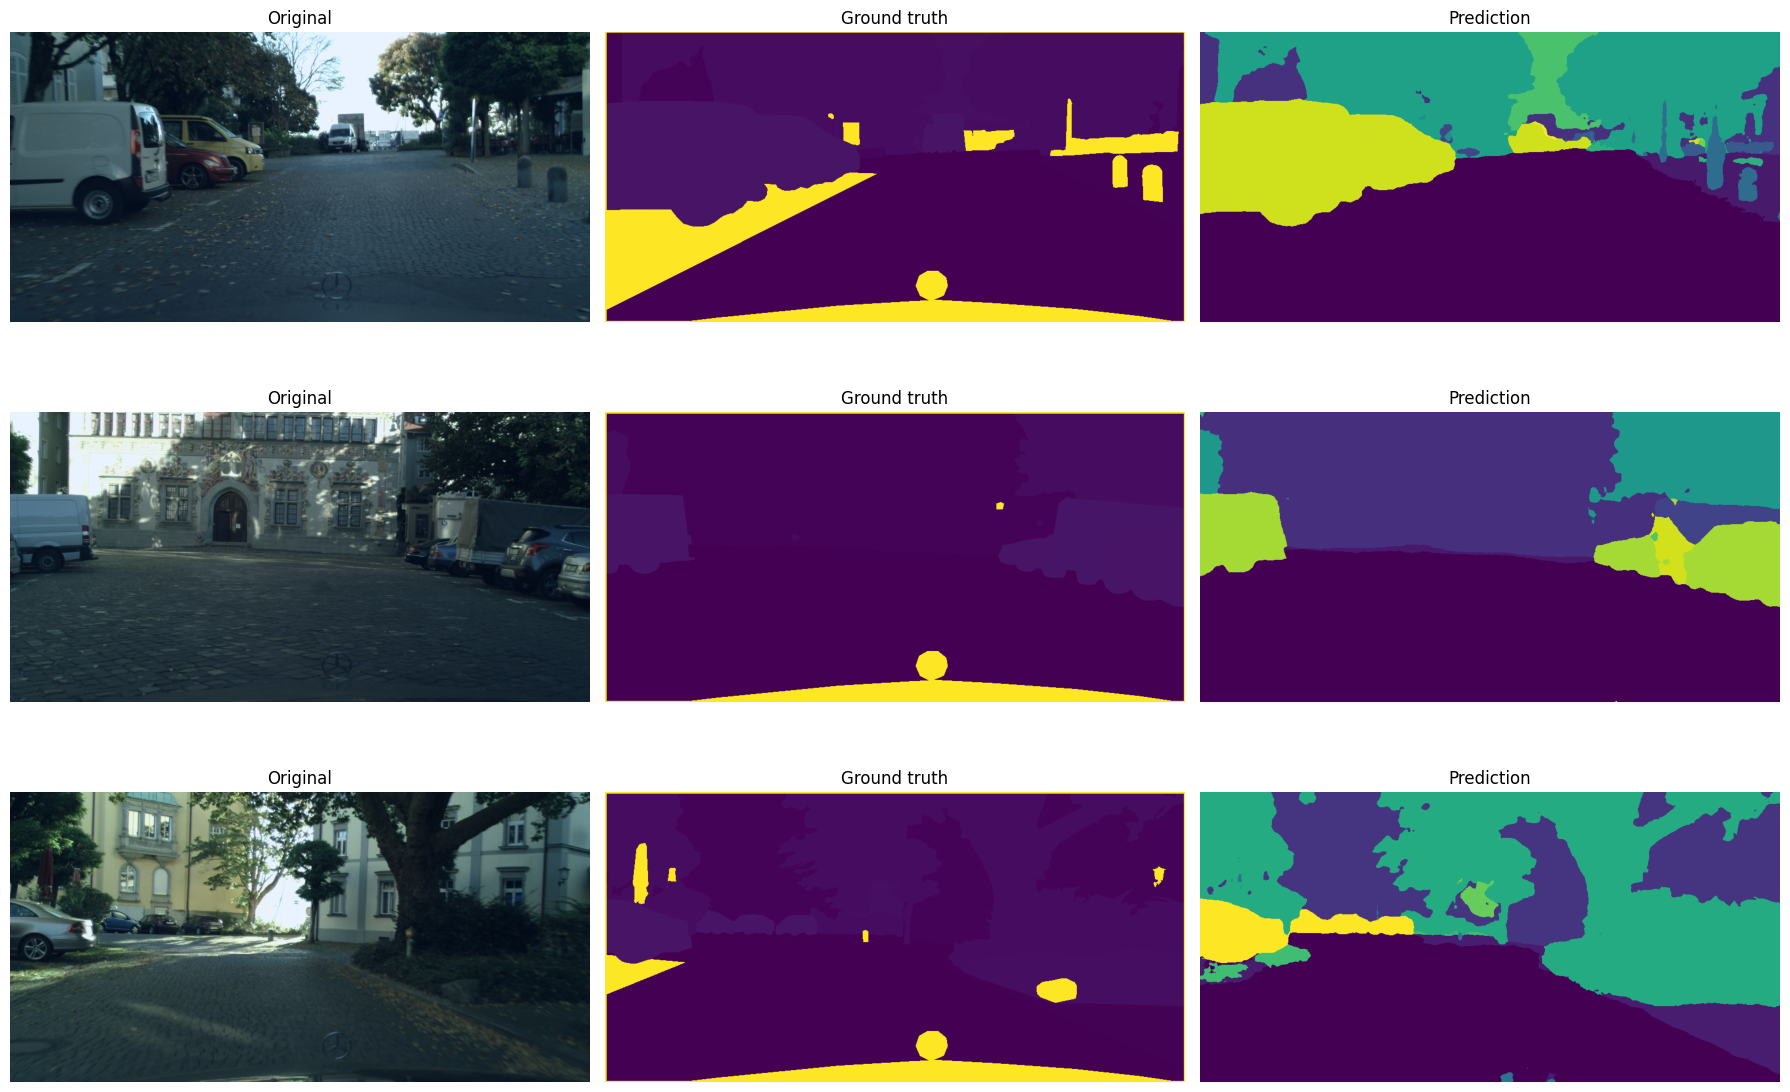

In [ ]:
best_model_path = trainer.checkpoint_callback.best_model_path

best_model = RoadModel.load_from_checkpoint(best_model_path)
best_model.to(CONFIG["device"])
best_model.eval()


val_results = trainer.validate(best_model, datamodule=dm)[0]

metrics_data = {
    "Metric": ["Loss", "mIoU", "Percent"],
    "Value": [
        f"{val_results['val_loss']:.4f}",
        f"{val_results['val_miou']:.4f}",
        f"{val_results['val_miou']*100:.2f}%"
    ]
}
df = pd.DataFrame(metrics_data)

print("\n" + "="*30)
print("Results:" + "\n")
print("="*30)
display(df)

def visualize_predictions(model, datamodule, num_samples=3):
    model.to(CONFIG["device"])
    model.eval()

    val_loader = datamodule.val_dataloader()
    images, masks = next(iter(val_loader))

    images = images.to(CONFIG["device"])
    with torch.no_grad():
        logits = model(images)
        preds = torch.argmax(logits, dim=1)

    images = images.cpu()
    masks = masks.cpu()
    preds = preds.cpu()

    plt.figure(figsize=(18, num_samples * 4))

    for i in range(num_samples):
        img = images[i].permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min())

        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(img)
        plt.title("Original")
        plt.axis("off")

        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(masks[i])
        plt.title("Ground truth")
        plt.axis("off")

        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(preds[i])
        plt.title(f"Prediction")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

visualize_predictions(best_model, dm)

In [ ]:
best_model_path = trainer.checkpoint_callback.best_model_path

model_name = os.path.basename(best_model_path)

current_task = Task.get_task(task_id=task.id)

current_task.update_output_model(
    model_path=best_model_path,
    model_name=model_name,
    iteration=trainer.current_epoch
)

'https://files.clear.ml/Segmentation_Urban_Scene_CourseWork/SegFormer_B2_Cityscapes_E4_SourceConsistency.e7bc023c295e4ef89b1b94159b933b3f/models/segformer-b2-E4-cityscapes-epoch=23-val_miou=0.7026.ckpt'

In [ ]:
task.close()

In [ ]:
from google.colab import runtime
runtime.unassign()